Importing library

# Langkah 1: Inisialisasi Matriks Keputusan

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# 1. Menyiapkan data alternatif
alternatif = ['Provider_A', 'Provider_B', 'Provider_C']
kriteria = ['Harga', 'Latensi', 'Reliabilitas']
# Matriks Keputusan (X)
data_x = np.array([
[5, 20, 95], # Provider A
[8, 10, 99], # Provider B
[3, 50, 90] # Provider C
])
df_x = pd.DataFrame(data_x, columns=kriteria, index=alternatif)
print("Matriks Keputusan Awal:")
print(df_x)

Matriks Keputusan Awal:
            Harga  Latensi  Reliabilitas
Provider_A      5       20            95
Provider_B      8       10            99
Provider_C      3       50            90


# Langkah 2: Menentukan Bobot dan Jenis Kriteria

In [34]:
# Bobot (W) -> Total harus 1.0 (100%)
bobot = np.array([0.4, 0.3, 0.3])
# Jenis Kriteria (1 untuk Benefit, 0 untuk Cost)
# Harga: Cost, Latensi: Cost, Reliabilitas: Benefit
jenis = [0, 0, 1]

# Langkah 3: Proses Normalisasi Matriks (RR)

In [35]:
def normalisasi(X, jenis_kriteria):
    R = np.zeros(X.shape)
    for j in range(X.shape[1]):
        if jenis_kriteria[j] == 1: # Benefit
            R[:, j] = X[:, j] / np.max(X[:, j])
        else: # Cost
            R[:, j] = np.min(X[:, j]) / X[:, j]
    return R
R = normalisasi(data_x, jenis)
df_r = pd.DataFrame(R, columns=kriteria, index=alternatif)
print("\nMatriks Ternormalisasi (R):")
print(df_r)


Matriks Ternormalisasi (R):
            Harga  Latensi  Reliabilitas
Provider_A  0.600      0.5      0.959596
Provider_B  0.375      1.0      1.000000
Provider_C  1.000      0.2      0.909091


# Langkah 4: Perangkingan (Skor Preferensi VV)

In [36]:
# Menghitung nilai V = R * W
V = np.dot(R, bobot)
df_hasil = pd.DataFrame({'Skor_Akhir': V}, index=alternatif)
df_hasil = df_hasil.sort_values(by='Skor_Akhir', ascending=False)
print("\nHasil Perankingan Alternatif:")
print(df_hasil)


Hasil Perankingan Alternatif:
            Skor_Akhir
Provider_B    0.750000
Provider_C    0.732727
Provider_A    0.677879


# Langkah 5: Visualisasi Hasil Keputusan

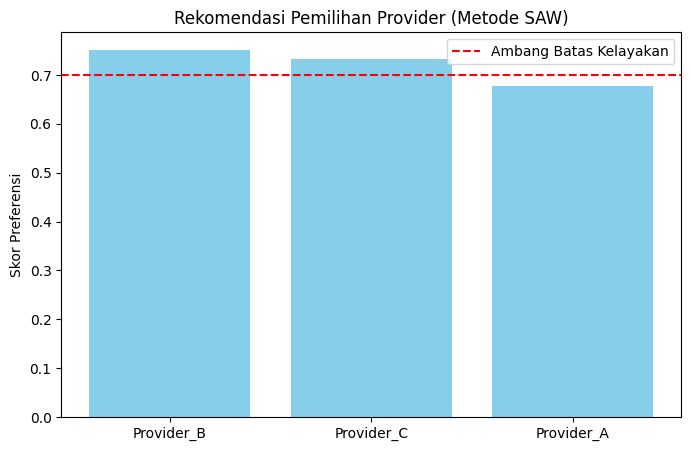

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(df_hasil.index, df_hasil['Skor_Akhir'], color='skyblue')
plt.axhline(y=0.7, color='red', linestyle='--', label='Ambang Batas Kelayakan')
plt.title("Rekomendasi Pemilihan Provider (Metode SAW)")
plt.ylabel("Skor Preferensi")
plt.legend()
plt.show()